# DL058 自编码器与潜在表示

从手算到完整训练，检查“重构好”是否意味着标签容易被读取。Run All真正重新训练AE与DAE共六次，每次250步、批64、CPU单线程。数据原创合成，无下载，无GPU，无API。输出写入notebook_replay，不覆盖随包outputs。先读lab.pdf并写下预测。

In [1]:
from pathlib import Path
import sys,json
import numpy as np
import torch
candidates=[Path.cwd(),Path.cwd()/"units"/"058"]
ROOT=next((p.resolve() for p in candidates if p.name=="058" and (p/"experiment.py").is_file()),None)
if ROOT is None: raise RuntimeError("请从058目录或课程仓库根目录启动")
sys.path.insert(0,str(ROOT))
from experiment import Autoencoder,make_data,reconstruction_loss,sparse_penalty,fit_probe,run
print("Python",sys.version.split()[0],"Torch",torch.__version__,"NumPy",np.__version__)
print("本次输出：058/notebook_replay，相对于单元目录")

Python 3.12.14 Torch 2.14.1+cpu NumPy 2.3.5
本次输出：058/notebook_replay，相对于单元目录


## 1 先看数据与shape
三个划分每类平衡，训练前128例标签的比例不另作调整。全部640个训练输入用于无标签表示训练；只有前128个标签用于探测。写下为什么不用测试输入估计中心化均值。

In [2]:
data=make_data()
for split in ["train","validation","test"]:
    print(split,data["x_"+split].shape,np.unique(data["y_"+split],return_counts=True))
model=Autoencoder()
x=torch.from_numpy(data["x_train"][:4])
print("input / latent / reconstruction",tuple(x.shape),tuple(model.encoder(x).shape),tuple(model(x).shape))
print("参数",sum(p.numel() for p in model.parameters()),"公式",296+33*2)
print("有标签前缀",np.unique(data["y_train"][:128],return_counts=True))

train (640, 8) (array([-1.,  1.], dtype=float32), array([320, 320]))
validation (160, 8) (array([-1.,  1.], dtype=float32), array([80, 80]))
test (320, 8) (array([-1.,  1.], dtype=float32), array([160, 160]))
input / latent / reconstruction (4, 8) (4, 2) (4, 8)
参数 362 公式 362
有标签前缀 (array([-1.,  1.], dtype=float32), array([69, 59]))


## 2 手算后让自动微分核对
预期z=1.5，loss=0.625，编码梯度(-1,0.5)，解码梯度(-0.75,1.5)。这里没有ReLU，用普通SGD演示一次更新，不声称等于主实验Adam的一步。

In [3]:
x=torch.tensor([[2.,-1.]])
e=torch.tensor([[.5],[-.5]],requires_grad=True)
d=torch.tensor([[1.,0.]],requires_grad=True)
z=x@e;prediction=z@d;loss=reconstruction_loss(prediction,x)
loss.backward()
print("z",z.detach().numpy(),"prediction",prediction.detach().numpy(),"loss",loss.item())
print("encoder gradient",e.grad.numpy(),"decoder gradient",d.grad.numpy())
with torch.no_grad():
    updated=(x@(e-.1*e.grad))@(d-.1*d.grad)
print("一次SGD重构",updated.numpy(),"loss",reconstruction_loss(updated,x).item())
print("L1活动惩罚",sparse_penalty(torch.tensor([[2.,-1.]]),.1).item())

z [[1.5]] prediction [[1.5 0. ]] loss 0.625
encoder gradient [[-1. ]
 [ 0.5]] decoder gradient [[-0.75  1.5 ]]
一次SGD重构 [[ 1.8812501  -0.26250002]] loss 0.2790038287639618
L1活动惩罚 0.15000000596046448


## 3 PCA的线性基准
四个点已中心化。保留横轴后残差平方和为2，除以4行×2列得到0.25。奇异值的符号没有意义；子空间与重构才是本题对象。

In [4]:
X=np.array([[3.,0.],[-3.,0.],[0.,1.],[0.,-1.]])
u,s,vt=np.linalg.svd(X,full_matrices=False)
V=vt[:1].T
recon=X@V@V.T
print("squared singular values",s*s,"reconstruction",recon)
print("MSE",np.mean((X-recon)**2),"discarded energy /ND",np.sum(s[1:]**2)/X.size)

squared singular values [18.  2.] reconstruction [[ 3.  0.]
 [-3.  0.]
 [ 0.  0.]
 [ 0.  0.]]
MSE 0.25 discarded energy /ND 0.25000000000000006


## 4 先测试随包证据
测试检查全部六份权重、11行结果和320例的重放一致性，文件缺失不能通过。包括禁止loss广播、空输入、错误惩罚等检查；普通与-O测试也在终端单独执行。

In [5]:
from test_experiment import main as check_package
check_package(ROOT/"outputs")

PASS: hand gradients and SGD, loss guards, L1, PCA, train-only probe, 11 rows, all six exact checkpoints and full-test replay


## 5 完整重新训练
六次训练固定250步、每步64例，共96000样本曝光。DAE的输入受扰而目标保持干净；没有根据测试或验证标签挑最佳种子或检查点。实际运行时长随机器变化，不把“快”当评价指标。

In [6]:
REPLAY=ROOT/"notebook_replay"
result=run(REPLAY)
print(json.dumps(result["protocol"],ensure_ascii=False,indent=2))
print("runtime",result["runtime"])
check_package(REPLAY)

{
  "seeds": [
    5801,
    5802,
    5803
  ],
  "steps": 250,
  "batch": 64,
  "lr": 0.005,
  "bottleneck": 2,
  "architecture": "8->16 ReLU->2->16 ReLU->8",
  "noise_std": 0.5,
  "split_sizes": {
    "train": 640,
    "validation": 160,
    "test": 320
  },
  "labeled_probe_train": 128,
  "ridge": 1.0,
  "normalization": "subtract full training input mean only for AE/PCA; probe feature mean/std fit on128 labeled training examples",
  "selection": "fixed250 steps; no checkpoint search, no tuning with test or validation labels",
  "max_train_seconds_per_run": 120,
  "metrics": "MSE averaged over all N*8 coordinates; probe accuracy on320 test examples",
  "scope": "3 initializations, one fixed data split; no significance or universal representation claim"
}
runtime {'python': '3.12.14', 'torch': '2.14.1+cpu', 'numpy': '2.3.5', 'threads': 1, 'device': 'cpu', 'wall_seconds': 0.7629778829996212}
PASS: hand gradients and SGD, loss guards, L1, PCA, train-only probe, 11 rows, all six exact 

## 6 把三种任务分别汇总
干净重构、受扰输入恢复、标签预测是三个不同问题。raw使用8维，其他表示2维；随机解码器未训练。每方法保留全部初始化，均值不是最佳值。

In [7]:
for name in ["raw","pca2","random2","ae","dae"]:
    rows=[r for r in result["results"] if r["representation"]==name]
    print(name)
    for key in ["test_reconstruction_mse","corrupted_test_denoising_mse","probe_accuracy"]:
        values=np.array([r[key] for r in rows])
        print(" ",key,"mean",float(values.mean()),"min",float(values.min()),"max",float(values.max()))
    print(" 正确数/320",[r["probe_correct"] for r in rows])
ae=np.mean([r["corrupted_test_denoising_mse"] for r in result["results"] if r["representation"]=="ae"])
dae=np.mean([r["corrupted_test_denoising_mse"] for r in result["results"] if r["representation"]=="dae"])
print("DAE绝对改善",ae-dae,"相对改善",(ae-dae)/ae)

raw
  test_reconstruction_mse mean 0.0 min 0.0 max 0.0
  corrupted_test_denoising_mse mean 0.24312858283519745 min 0.24312858283519745 max 0.24312858283519745
  probe_accuracy mean 1.0 min 1.0 max 1.0
 正确数/320 [320]
pca2
  test_reconstruction_mse mean 0.03896292671561241 min 0.03896292671561241 max 0.03896292671561241
  corrupted_test_denoising_mse mean 0.09683980792760849 min 0.09683980792760849 max 0.09683980792760849
  probe_accuracy mean 0.478125 min 0.478125 max 0.478125
 正确数/320 [153]
random2
  test_reconstruction_mse mean 1.6362497011820476 min 1.613305687904358 max 1.6808388233184814
  corrupted_test_denoising_mse mean 1.6385416587193806 min 1.6161859035491943 max 1.683203101158142
  probe_accuracy mean 0.5145833333333334 min 0.453125 max 0.553125
 正确数/320 [177, 145, 172]
ae
  test_reconstruction_mse mean 0.042547023544708885 min 0.04180938005447388 max 0.04303158447146416
  corrupted_test_denoising_mse mean 0.11383391171693802 min 0.11032267659902573 max 0.11894786357879639
  

## 7 核对数值重放
同一环境下应高度一致，计时字段不要求相同。跨版本结果发生差异时保留差值与版本，不覆写参考结果。1e-5用于发现需要调查的变化，而不是跨平台逐位承诺。

In [8]:
reference=json.loads((ROOT/"outputs/results.json").read_text())
for old,new in zip(reference["results"],result["results"]):
    key=(old["representation"],old["seed"])
    if key!=(new["representation"],new["seed"]):raise RuntimeError("row identity changed")
    deltas={k:abs(old[k]-new[k]) for k in ["test_reconstruction_mse","corrupted_test_denoising_mse","probe_accuracy"]}
    print(key,deltas)
    if max(deltas.values())>1e-5: raise RuntimeError("与参考有差异，请记录并检查环境与协议")

('raw', 0) {'test_reconstruction_mse': 0.0, 'corrupted_test_denoising_mse': 0.0, 'probe_accuracy': 0.0}
('pca2', 0) {'test_reconstruction_mse': 0.0, 'corrupted_test_denoising_mse': 0.0, 'probe_accuracy': 0.0}
('random2', 5801) {'test_reconstruction_mse': 0.0, 'corrupted_test_denoising_mse': 0.0, 'probe_accuracy': 0.0}
('ae', 5801) {'test_reconstruction_mse': 0.0, 'corrupted_test_denoising_mse': 0.0, 'probe_accuracy': 0.0}
('dae', 5801) {'test_reconstruction_mse': 0.0, 'corrupted_test_denoising_mse': 0.0, 'probe_accuracy': 0.0}
('random2', 5802) {'test_reconstruction_mse': 0.0, 'corrupted_test_denoising_mse': 0.0, 'probe_accuracy': 0.0}
('ae', 5802) {'test_reconstruction_mse': 0.0, 'corrupted_test_denoising_mse': 0.0, 'probe_accuracy': 0.0}
('dae', 5802) {'test_reconstruction_mse': 0.0, 'corrupted_test_denoising_mse': 0.0, 'probe_accuracy': 0.0}
('random2', 5803) {'test_reconstruction_mse': 0.0, 'corrupted_test_denoising_mse': 0.0, 'probe_accuracy': 0.0}
('ae', 5803) {'test_reconstructi

## 8 保存的探测器如何预测
只读取前128例统计保存的mean/scale/weights。最后一列1对应截距；score不是概率。下列例子复算AE5801全部320个测试预测。

In [9]:
plots=np.load(REPLAY/"plot_data.npz",allow_pickle=False)
probe=np.load(REPLAY/"probe_ae_5801.npz",allow_pickle=False)
z=plots["latent_ae_5801"].astype(float)
A=np.column_stack([(z-probe["mean"])/probe["scale"],np.ones(len(z))])
scores=A@probe["weights"]
correct=int(np.sum(np.where(scores>=0,1.,-1.)==data["y_test"]))
print("正确",correct,"分母",len(z),"准确率",correct/len(z))
print("保存score最大差",np.max(np.abs(scores-probe["scores"])))

正确 150 分母 320 准确率 0.46875
保存score最大差 0.0


## 9 从本次结果重新画图
潜在图的颜色只在评价中使用。曲线对数轴、所有种子散点、固定同一测试噪声，均需在解释中注明。中文图需要Noto Sans CJK或DL_CJK_FONT设置。

01_latent.png


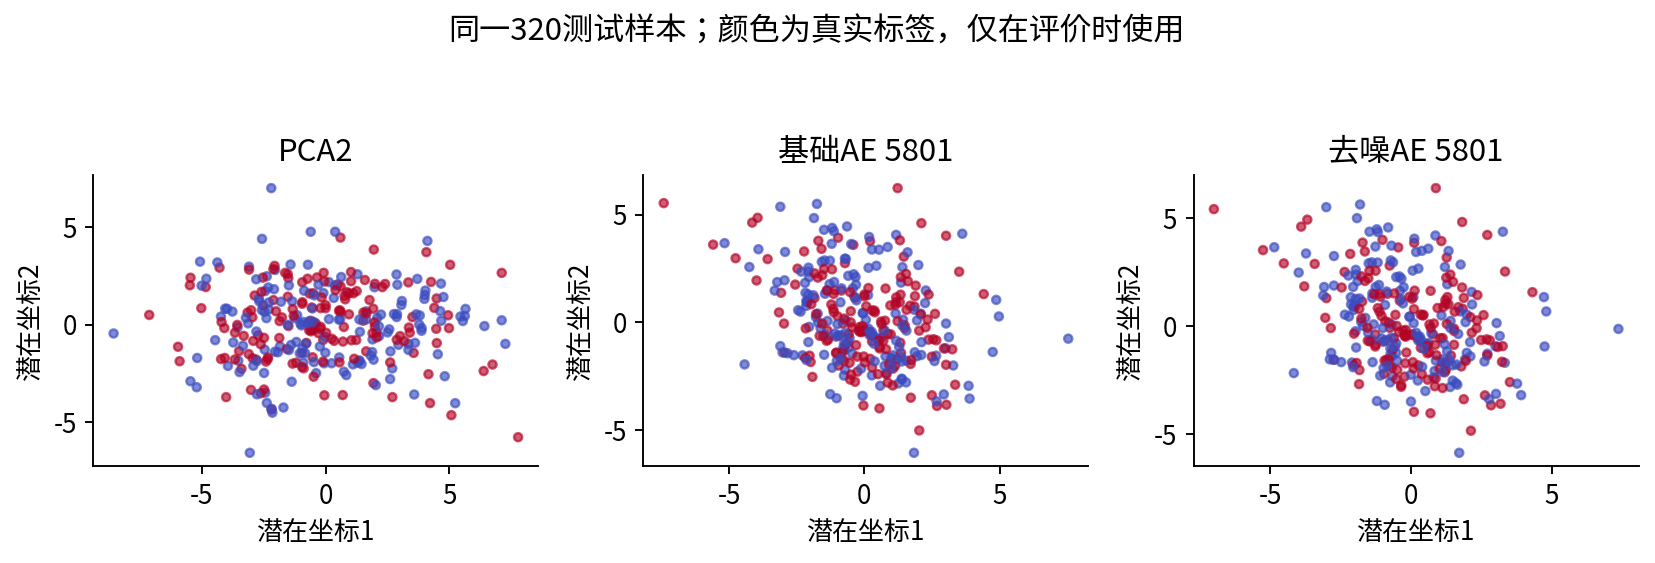

02_spectrum.png


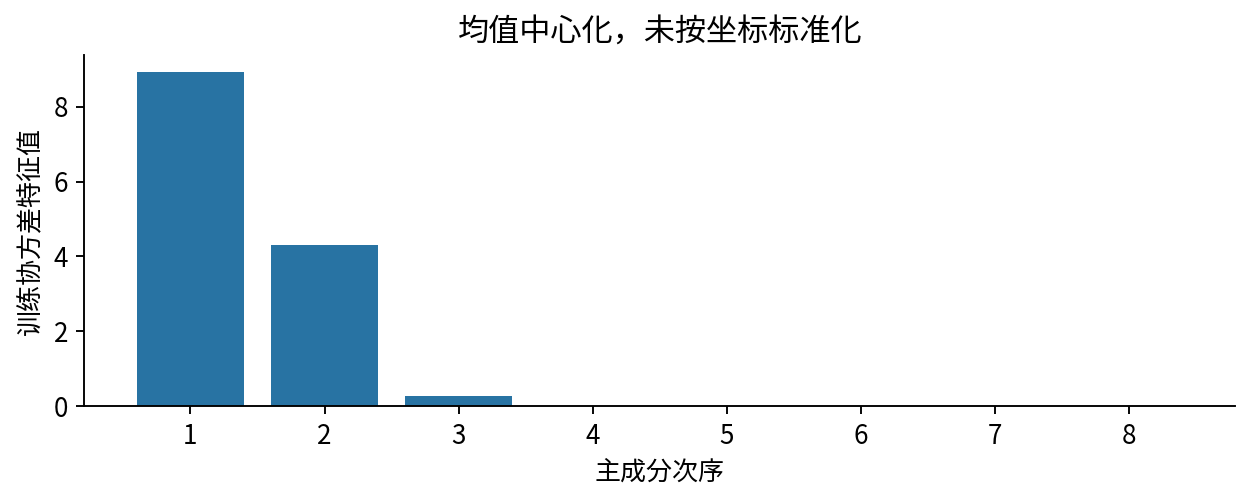

03_training.png


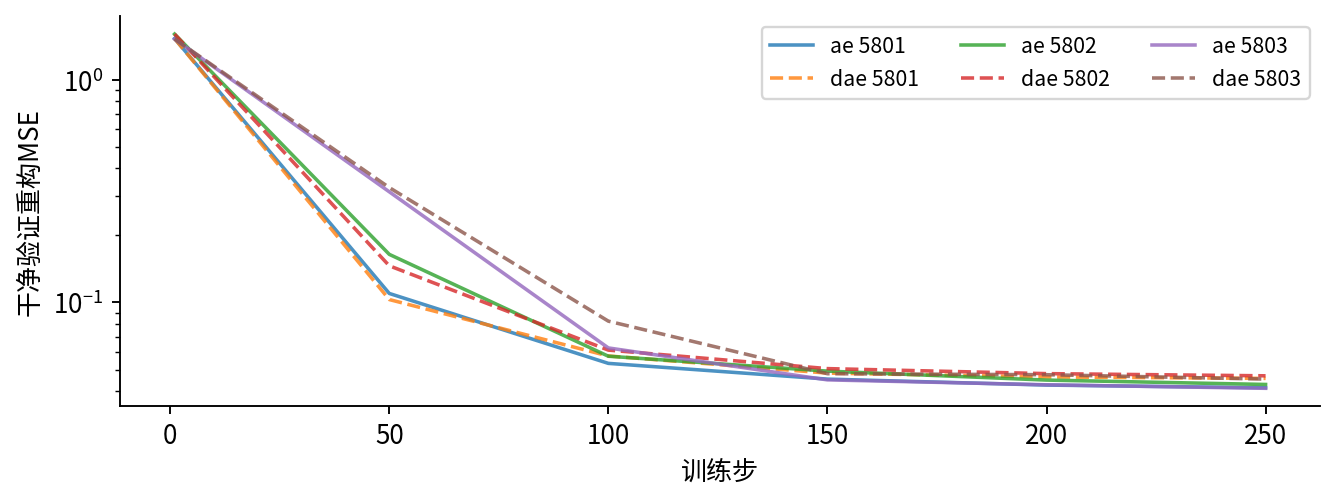

04_reconstruction_probe.png


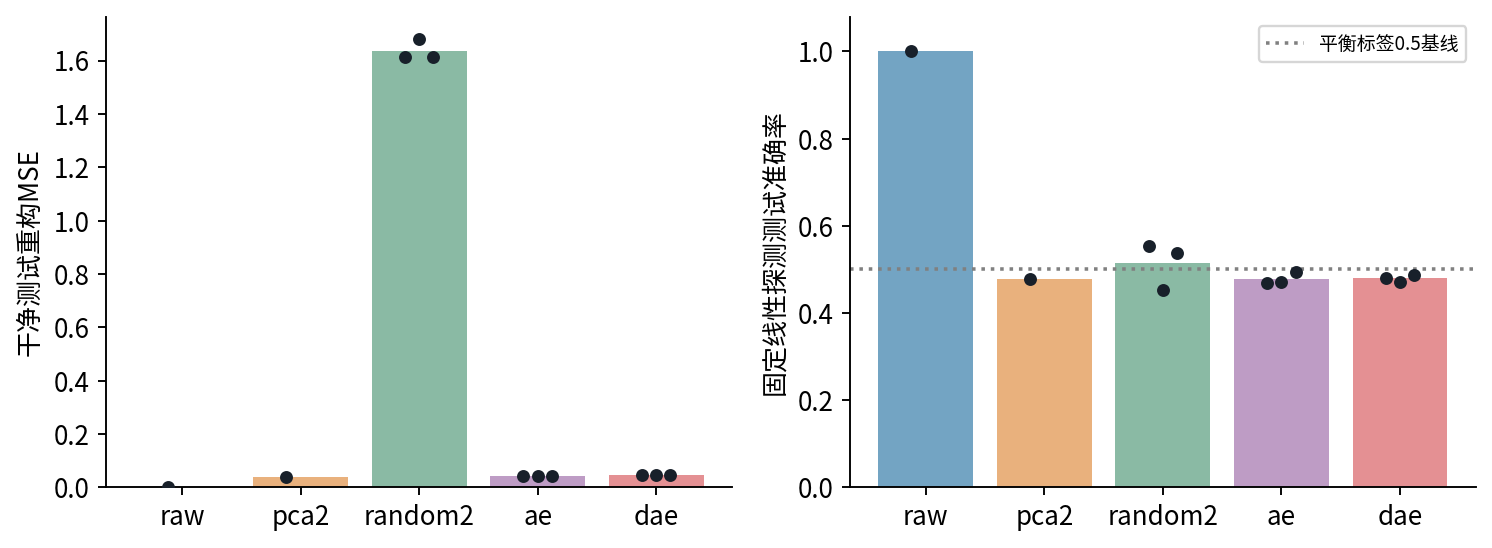

05_denoising.png


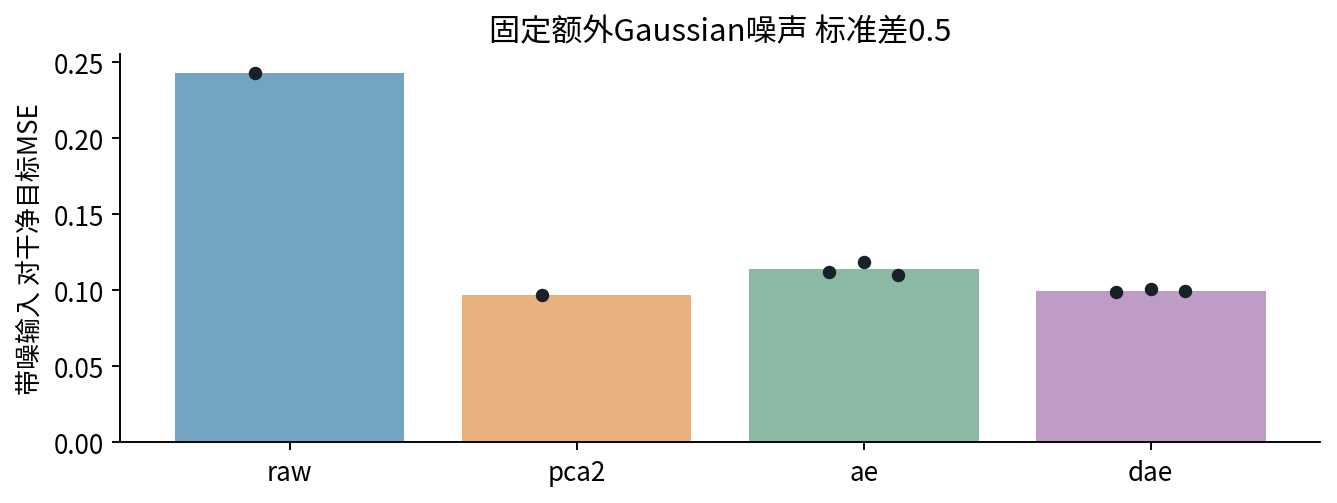

06_encoder_decoder.png


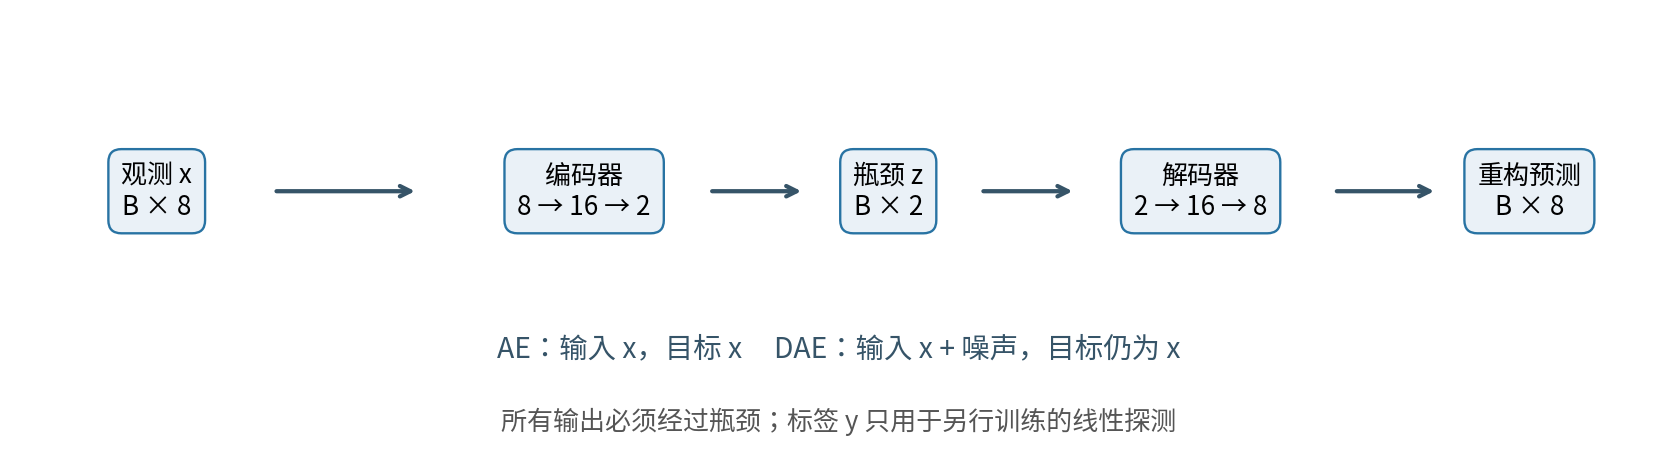

In [10]:
from make_figures import main as make_figures
from IPython.display import display,Image
make_figures(REPLAY/"results.json",REPLAY/"figures")
for path in sorted((REPLAY/"figures").glob("*.png")):
    print(path.name)
    display(Image(filename=str(path)))

## 10 独立作答
1. 重构很小而线性探测接近0.5的机制是什么？2. DAE改善哪个指标，是否胜过PCA？3. 三种子不能覆盖哪些不确定性？4. 把瓶颈扩到3时，如何重新规定协议而不反复挑测试集？请在另一个记录文件中作答，answers.pdf用于做完后核对。

本Notebook的完整Run All已结束；随包结果不是稀疏AE实验，也不是现实图像语义评测。